# Wprowadzenie do obliczeń kwantowych i środowiska Qiskit

## 1. Paradygmat obliczeń kwantowych
Klasyczna teoria informacji opiera się na bitach przyjmujących stany z dyskretnego zbioru $\{0, 1\}$. Informatyka kwantowa rozszerza ten model wprowadzając kubit. Stan pojedynczego kubitu jest wektorem w dwuwymiarowej przestrzeni (konkretnie przestrzeni Hilberta) nad ciałem liczb zespolonych $\mathbb{C}$.

$$|\psi\rangle = \alpha |0\rangle + \beta |1\rangle$$

Wielkości $\alpha$ oraz $\beta$ to zespolone _amplitudy prawdopodobieństwa_ będące jednym (dowolnym) pierwiastkiem zespolonym z wartości prawdopodobieństwa znalezienia kubitu w stanie odpowiednio $1$ lub $0$. (Postulat 1)


## 2. Architektura biblioteki Qiskit
Qiskit (Quantum Information Science Kit) to platforma programistyczna pozwalająca na tworzenie, kompilację (przede wszystkim do QASM) oraz uruchamianie algorytmów kwantowych z użyciem języka Python. Środowisko to posiada pełen zestaw funkcjonalności:
* **QuantumCircuit**: Podstawowy obiekt reprezentujący obwód kwantowy. Służy do alokacji rejestrów i definiowania sekwencji bramek logicznych.
* **Qiskit Aer**: Symulator pozwalający na testowanie układów bez dostępu do rzeczywistego procesora QPU (Quantum Processing Unit) oraz umożliwia wprowadzanie modeli szumów.
* **Transpiler**: Moduł odpowiedzialny za optymalizację obwodu i mapowanie logicznych kubitów na topologię fizycznego procesora uwzględniając ograniczenia sprzętowe połączeń międzykubitowych. Więcej informacji na temat transpilacji obwodów kwantowych pojawi się przy okazji omawiania budowy QPU.
* **Primitives (Sampler i Estimator)**: Interfejsy optymalizujące zbieranie danych wyjściowych

Wykorzystanie powyższego systemu pozwala zapisać matematyczny formalizm bezpośrednio w postaci kodu poddawanego ewaluacji numerycznej i eksperymentalnej.

# Część praktyczna: Wprowadzenie do Qiskit

Poniżej znajduje się praktyczne wprowadzenie do projektowania obwodów kwantowych, ich wizualizacji oraz symulacji przy użyciu biblioteki **Qiskit**.

In [79]:
# Instalacja Qiskit, biblioteki symulatorów Aer oraz narzędzi do wizualizacji pylatexenc
!pip install -U "qiskit[visualization]" qiskit-aer qiskit-ibm-runtime qiskit-addon-cutting pylatexenc

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.14/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

## 1. Tworzenie i wizualizacja obwodów kwantowych

Stwórzmy prosty obwód generujący stan splątany Bella $\ket{\Phi^{+}}=\frac{|00\rangle + |11\rangle}{\sqrt{2}}$. Użyjemy bramki Hadamarda ($H$) oraz kontrolowanego-NOT ($CX$).

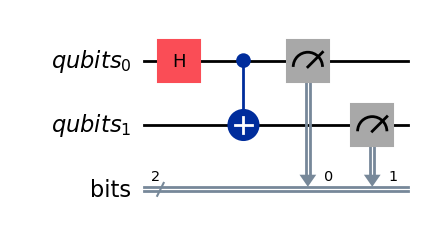

In [65]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

# Tworzymy rejestr kwantowy (listę kubitów) nazwany "qubits" i zawierającą 2 kubity zainicjowane zerami
qr = QuantumRegister(2, name='qubits')

# Tworzymy rejestr (listę bitów) nazwany "bits" i zawierającą 2 bity zainicjowane zerami
cr = ClassicalRegister(2, name='bits')

# Tworzymy obwód z rejestrem kwantowym qr i klasycznym cr
qc = QuantumCircuit(qr, cr)

# Nakładamy bramkę Hadamarda na kubit 0
qc.h(0)

# Nakładamy bramkę CX (CNOT) z kubitu 0 (kontrolny) na kubit 1 (docelowy)
qc.cx(0, 1)

# Dodajemy pomiary na odpowiadające bity klasyczne: qubit 0 na bit 0, qubit 1 na bit 1
qc.measure([0, 1], [0, 1])

# Rysujemy obwód w estetycznej formie graficznej 'mpl' (Matplotlib)
qc.draw(output='mpl')

Spróbuj poeksperymentować modyfikując powyższy kod używając różnych komponentów, usuwając nazwy itp. <br>
Uwaga: Zwyczajowo rejestr klasyczny oznacza się podwójną linią. Jeśli stan rejestru posiadającego więcej niż 1 element nie jest modyfikowany w nietrywialny sposób (dotyczy to zawsze rejestru klasycznego, a czasami też kwantowego) możemy zapisać go jedną przekreśloną linią niezależnie od liczby elementów (bitów/kubitów) (tę można zapisać zaraz obok nazwy - tak jak to robi *IBM Quantum Composer* lub zaraz nad skreśleniem, tak jak robi to Qiskit. <br>
Na wizualizacji poniżej mamy dwa bity, więc Qiskit oznaczył je podwójną linią, którą skreślił i zaznaczył liczbę bitów: 2

## 2. Wizualizacja stanu na Sferze Blocha i Dysku Fazowym (QSphere)

Aby zwizualizować stan kwantowy przed dokonaniem pomiaru, użyjemy klasy `Statevector` z biblioteki Qiskit.

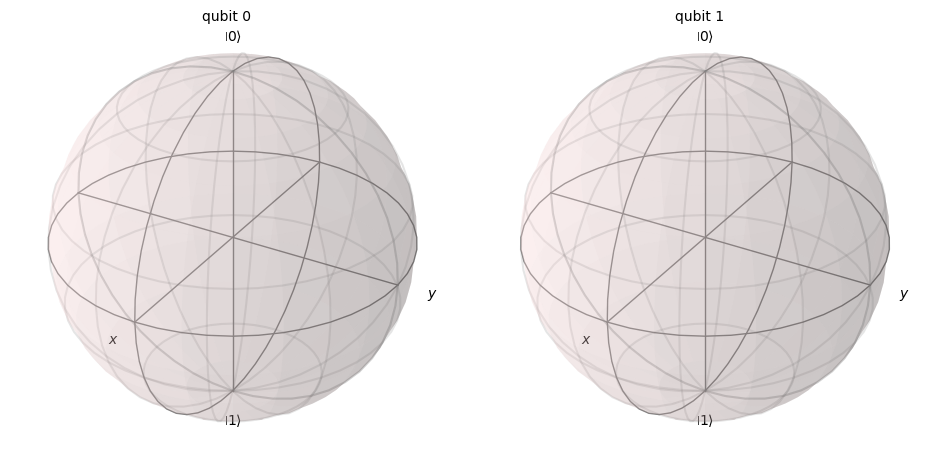

In [61]:
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_state_qsphere

# Tworzymy obwód tworzący parę bella phi+ bez pomiarów, aby zbadać stan kwantowy
qc_state = QuantumCircuit(2)
qc_state.h(0)
qc_state.cx(0, 1) # Zakomentuj tę linię aby zobaczyć wektor stanu

# Pobieramy wektor stanu
state = Statevector.from_instruction(qc_state)

# 1. Wizualizacja na Sferze Blocha dla każdego kubitu z osobna
display(plot_bloch_multivector(state))

*Uwaga: Dla stanów splątanych takich jak stan Bella, pojedyncze kubity nie mają określonego stanu czystego na sferze Blocha (wektory kurczą się do środka sfery). Możesz zmodyfikować powyższy kod usuwając z niego bramkę CX lub dodając inne. Aby zobaczyć pełną korelację fazową i amplitudy całego układu wielokubitowego, często używa się **QSphere** (kwantowa sfera stanów, będąca uogólnieniem dysków fazowych):*

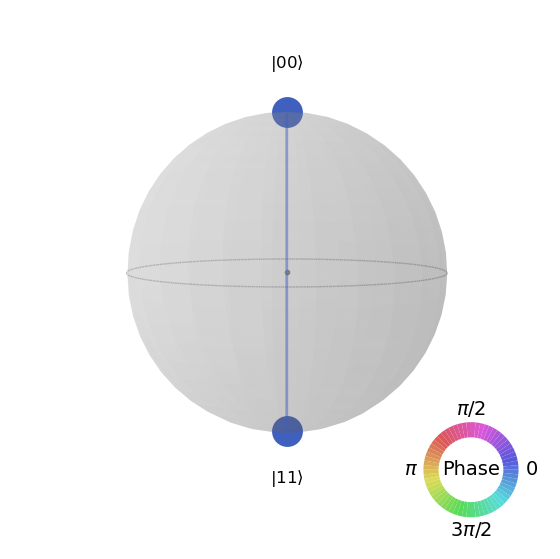

In [62]:
# 2. Wizualizacja stan Phi+ u za pomocą QSphere
plot_state_qsphere(state)

### Interaktywny Eksplorator Jednego Kubitu (Sfera Blocha)

Stan pojedynczego kubitu możemy zapisać parametrycznie jako:
$$|\psi\rangle = \cos(\theta/2)|0\rangle + e^{i\phi}\sin(\theta/2)|1\rangle$$
gdzie $\theta$ odpowiada za szerokość geograficzną na sferze Blocha, a $\phi$ za długość (fazę). Użyj poniższych suwaków, aby zobaczyć, jak zmiana parametrów wpływa na wektor stanu.

In [63]:
import numpy as np
import ipywidgets as widgets
from ipywidgets import interact
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

# Nie musisz rozumieć tej funkcji, wystarczy pomachać suwakami poniżej
def aktualizuj_sfe_blocha(theta, phi_fraction):
    # Obliczanie fazy jako ułamka liczby pi
    phi = phi_fraction * np.pi

    # Wyznaczenie amplitud stanu
    alpha = np.cos(theta / 2)
    beta = np.exp(1j * phi) * np.sin(theta / 2)

    # Tworzenie wektora stanu
    stan = Statevector([alpha, beta])

    # Wyświetlenie sfery
    display(plot_bloch_multivector(stan))
    print(f"Wektor stanu: [{alpha:.3f}] |0> + [{beta:.3f}] |1>")
    print(f"Prawdopodobieństwo |0>: {abs(alpha)**2:.3%}")
    print(f"Prawdopodobieństwo |1>: {abs(beta)**2:.3%}")

# Interaktywne suwaki dla kątów theta (0 do pi) oraz phi (0 do 2*pi)
interact(aktualizuj_sfe_blocha,
         theta=widgets.FloatSlider(min=0, max=np.pi, step=0.1, value=np.pi/2, description='Kąt θ (szer.):'),
         phi_fraction=widgets.FloatSlider(min=0, max=2.0, step=0.1, value=0.0, description='Faza φ (dł. π):'));

interactive(children=(FloatSlider(value=1.5707963267948966, description='Kąt θ (szer.):', max=3.14159265358979…

## 3. Uruchomienie na Symulatorze (Qiskit Aer)

Teraz zasymulujemy wielokrotne wykonanie naszego pierwszego obwodu z pomiarami, aby sprawdzić rozkład prawdopodobieństwa wyników zgodnie z twierdzeniem Borna. <br>
<b>Przypomnienie:</b>
**Twierdzenie Borna** - Prawdopodobieństwo otrzymania danej wartości przy pomiarze kubitu jest równe kwadratowi modułu amplitudy prawdopodobieństwa tej wartości.

Zliczenia wyników: {'00': 491, '11': 533}


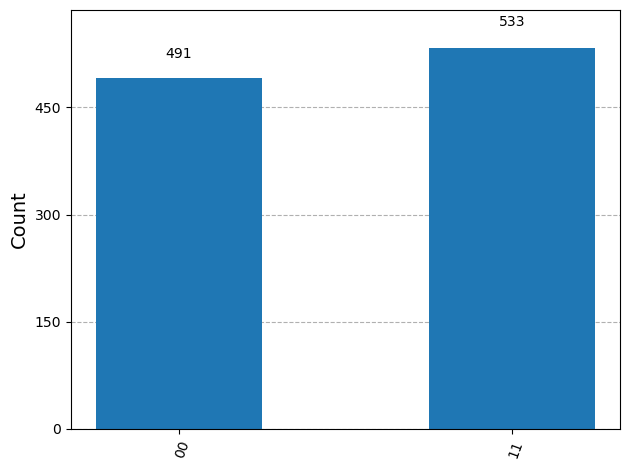

In [66]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# Tworzymy instancję lokalnego symulatora
simulator = AerSimulator()

# Uruchamiamy symulację obwodu 'qc' (zdefiniowanego w punkcie 1, zawierającego pomiary)
# Wykonamy 1024 powtórzenia (shots)
job = simulator.run(qc, shots=1024)
result = job.result()

# Pobieramy zliczenia stanów
counts = result.get_counts()
print("Zliczenia wyników:", counts)

# Wizualizacja wyników na histogramie
plot_histogram(counts)

## 2. Test Hadamarda

### 2. Test Hadamarda i estymacja wartości oczekiwanej

Test Hadamarda jest uniwersalnym algorytmem służącym do wyznaczania wartości oczekiwanej bramki ${U}$ dla określonego stanu ${|\psi\rangle}$. Architektura wymaga wprowadzenia dodatkowego kubitu kontrolnego zainicjalizowanego w stanie zera. Ewolucja całego układu, wykorzystująca bramki ${H}$ oraz dowolną kontrolowaną bramkę ${CU}$, prowadzi do znoszenia się i wzmacniania aplitud różnych stanów (to zjawisko nazywa się interferencją, a proces jej obliczania często określa się jako całkę (lub sumę) po historiach). Wyprowadza ona rozkład, w którym prawdopodobieństwo zaobserwowania stanu ${|0\rangle}$ na kubicie kontrolnym opisuje zależność:

${P(0)} = \frac{1}{2} (1 + \text{Re}(\langle\psi|{U}|\psi\rangle))$ (zobacz wyprowadzenie w notatce)

### 3. Obliczanie cosinusa dowolnego kąta za pomocą statystyki próbkowania

Chcąc wyznaczyć wartość $\cos({\theta})$, konstruujemy układ operujący bramką zmiany fazy ${P}({\theta})$, a stan docelowy określamy jako ${|1\rangle}$. Ponieważ część rzeczywista $e^{i{\theta}}$ jest z definicji postaci wykładniczej i trygonometrycznej liczby zespolonej równa $\cos({\theta})$, ogólny wzór testu Hadamarda upraszcza się do postaci:

$\cos({\theta}) = 2{P(0)} - 1$

Implementacja tego algorytmu polega na zebraniu wielu pomiarów ${P(0)}$ w celu minimalizacji błędu z odchyleń statystycznych i szumu, pozwalając na stabilną ewaluację.
Najczęściej przyjmowaną liczbą pomiarów jednego obwodu jest 1024.

### Interaktywny eksperyment z pomiarów

Zgodnie z twierdzeniem Borna, dla stanu $\ket{\Phi^+}$ prawdopodobieństwo pomiaru wynosi dokładnie $0.5$ dla $|00\rangle$ i $|11\rangle$. Jednak przy małej liczbie pomiarów (np. shots =10) błędy statystyczne są ogromne. Sprawdź za pomocą suwaka, od jakiej liczby pomiarów wyniki stabilizują się blisko idealnego poziomu 50%.

In [76]:
def eksperyment_shots(liczba_pomiarow):
    # Tworzenie obwodu Bella
    qc_exp = QuantumCircuit(2, 2)
    qc_exp.h(0)
    qc_exp.cx(0, 1)
    qc_exp.measure([0, 1], [0, 1])

    # Uruchomienie z wybraną liczbą shots
    job = simulator.run(qc_exp, shots=liczba_pomiarow)
    wyniki = job.result().get_counts()

    # Wyświetlenie zaktualizowanego histogramu
    display(plot_histogram(wyniki))

    # Obliczenie procentów dla czytelności
    for stan, ilosc in wyniki.items():
        print(f"Stan |{stan}>: {ilosc} razy ({ilosc/liczba_pomiarow:.2%})")

interact(eksperyment_shots,
         liczba_pomiarow=widgets.IntSlider(min=10, max=4000, step=39, value=100, description='Shots (Próby):'));

interactive(children=(IntSlider(value=100, description='Shots (Próby):', max=4000, min=10, step=39), Output())…

In [77]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

theta = np.pi / 3

qc = QuantumCircuit(2, 1)
qc.x(1)

qc.h(0)
qc.cp(theta, 0, 1)
qc.h(0)

qc.measure(0, 0)

sim = AerSimulator()
wyniki = sim.run(qc, shots=100000).result().get_counts()

p_0 = wyniki.get('0', 0) / 100000
cos_theta = 2 * p_0 - 1

print(f"Estymowana wartość cosinusa: {cos_theta:.5f}")
print(f"Wartość analityczna:         {np.cos(theta):.5f}")

Estymowana wartość cosinusa: 0.49960
Wartość analityczna:         0.50000
